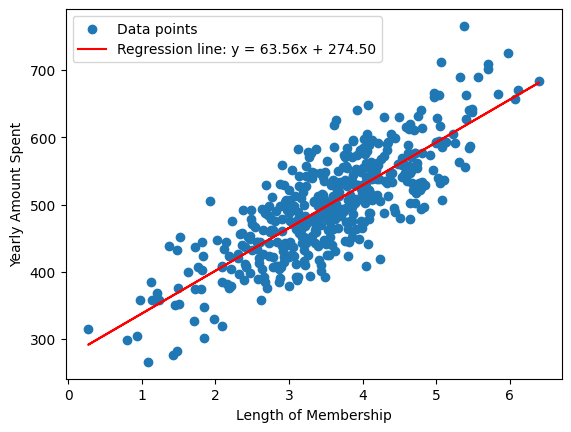

In [0]:
# Step 1: Filter out NULL values from Spark DataFrame
from pyspark.sql.functions import col

filtered_df = df.filter(
    col("Length of Membership").isNotNull() &
    col("Yearly Amount Spent").isNotNull()
)

# Step 2: Convert to Pandas DataFrame
pandas_df = filtered_df.select(
    "Length of Membership", "Yearly Amount Spent"
).toPandas()

# Step 3: Drop any remaining nulls in Pandas (extra safety)
pandas_df = pandas_df.dropna()

# Step 4: Perform regression and plot
import numpy as np
import matplotlib.pyplot as plt

x = pandas_df["Length of Membership"]
y = pandas_df["Yearly Amount Spent"]

# Fit regression line: y = a * x + b
a, b = np.polyfit(x, y, 1)

# Plotting
plt.scatter(x, y, label='Data points')
plt.plot(x, a * x + b, color='red', label=f'Regression line: y = {a:.2f}x + {b:.2f}')
plt.xlabel("Length of Membership")
plt.ylabel("Yearly Amount Spent")
plt.legend()
plt.show()
